**Name**: Premanshu Kusre | Prathamesh Deshmukh

  **Roll No**: CS23117 | CS23115

  **Subject**: Machine Learning  

  **Topic**: Network Anomaly Detection

  **Dataset**: UNSW-NB15  

  **Model Used**: Random Forest Classifier

**AIM**

To implement the Random Forest algorithm on the UNSW-NB15 dataset
for detecting network anomalies and classify network traffic as
normal or attack.

**DATASET DESCRIPTION**

The UNSW-NB15 dataset is a network intrusion detection dataset
containing modern network traffic with both normal and malicious
activities.

It includes multiple features such as protocol, service, packets,
bytes, and statistical attributes of network flows.

The target variable is 'label':
0 → Normal traffic
1 → Attack / anomaly

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
# Load dataset

df = pd.read_csv("/content/drive/MyDrive/ML Dataset/UNSW_NB15_training-set.csv")


In [46]:
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,...,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,...,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,...,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,...,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,...,1,3,0,0,0,2,3,0,Normal,0


In [47]:
df.shape

(82332, 45)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82332 entries, 0 to 82331
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 82332 non-null  int64  
 1   dur                82332 non-null  float64
 2   proto              82332 non-null  object 
 3   service            82332 non-null  object 
 4   state              82332 non-null  object 
 5   spkts              82332 non-null  int64  
 6   dpkts              82332 non-null  int64  
 7   sbytes             82332 non-null  int64  
 8   dbytes             82332 non-null  int64  
 9   rate               82332 non-null  float64
 10  sttl               82332 non-null  int64  
 11  dttl               82332 non-null  int64  
 12  sload              82332 non-null  float64
 13  dload              82332 non-null  float64
 14  sloss              82332 non-null  int64  
 15  dloss              82332 non-null  int64  
 16  sinpkt             823

In [49]:
df['label'].value_counts()

,count
label,
1,45332
0,37000


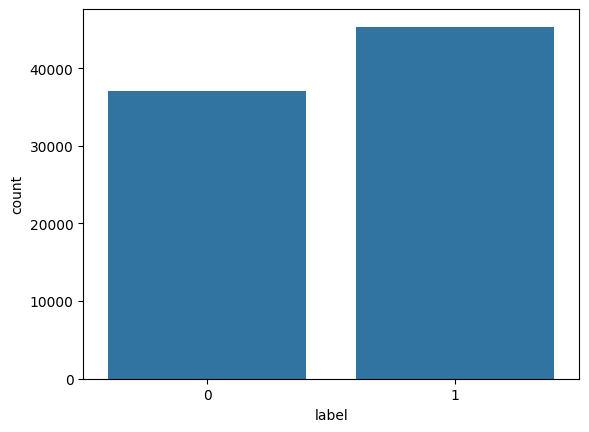

In [50]:
sns.countplot(x='label', data=df)
plt.show()

In [51]:
#Data Preprocessing

encoder = LabelEncoder()

df['proto'] = encoder.fit_transform(df['proto'])
df['service'] = encoder.fit_transform(df['service'])
df['state'] = encoder.fit_transform(df['state'])

In [52]:
df = df.drop(['attack_cat'], axis=1)

In [53]:
X = df.drop('label', axis=1)
y = df['label']

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [55]:
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (65865, 43)
Testing data shape: (16467, 43)


MODEL IMPLEMENTATION

In this section, the Random Forest algorithm is implemented
to classify network traffic as normal or anomalous.

In [56]:
#Train Random Forest Model

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [57]:
# Feature Importance

importances = rf_model.feature_importances_

feature_names = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)

,Feature,Importance
0,id,0.280254
10,sttl,0.090426
32,ct_state_ttl,0.080689
36,ct_dst_src_ltm,0.045560
9,rate,0.041432
7,sbytes,0.041324
12,sload,0.038877
27,smean,0.031794
41,ct_srv_dst,0.026542
1,dur,0.025178


In [58]:
#Prediction

y_pred = rf_model.predict(X_test)

In [59]:
#Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy: {:.2f}%".format(accuracy * 100))

Random Forest Accuracy: 99.92%


In [60]:
#Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[7408   10]
 [   3 9046]]


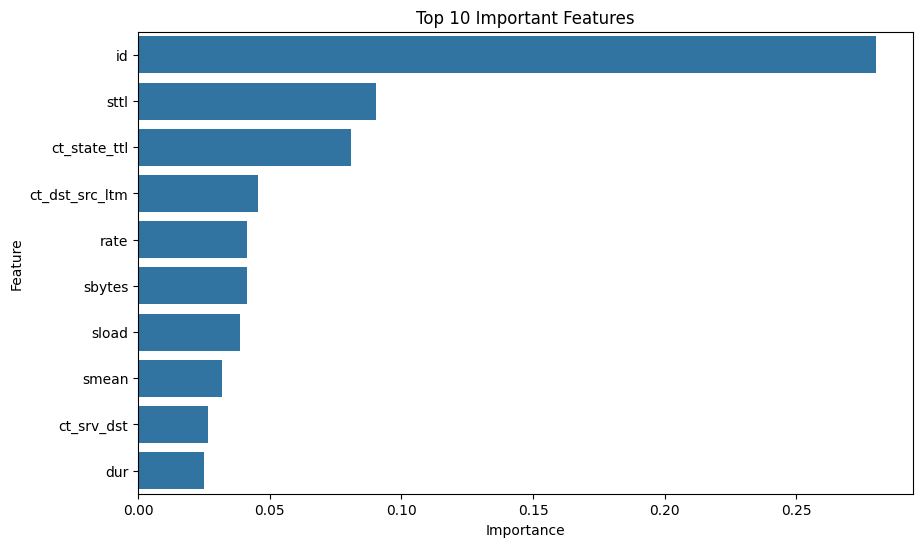

In [61]:
plt.figure(figsize=(10,6))

sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))

plt.title("Top 10 Important Features")
plt.show()

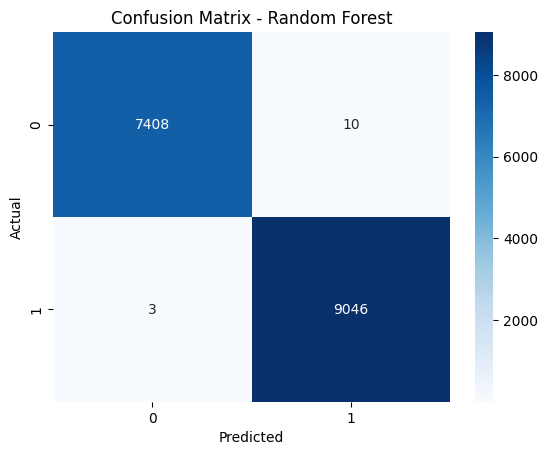

In [62]:
#Confusion Matrix Graph

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [63]:
#Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7418
           1       1.00      1.00      1.00      9049

    accuracy                           1.00     16467
   macro avg       1.00      1.00      1.00     16467
weighted avg       1.00      1.00      1.00     16467



RESULT

The Random Forest model was successfully implemented on the
UNSW-NB15 dataset for network anomaly detection.

The model achieved high accuracy and performed better than the
Decision Tree model due to its ensemble learning approach,
which combines multiple decision trees to improve prediction accuracy.